## Scenario

Patient comes →
We track their data step-by-step:

Add patient info
Calculate BMI
Add diagnosis
Add final recommendation

# Workflow
Start → Add Info → Calculate BMI → Diagnosis → Recommendation → End

In [1]:
# 1: Define State
from typing import TypedDict

class HealthState(TypedDict):
    name: str
    weight: float
    height: float
    bmi: float
    diagnosis: str
    recommendation: str

In [2]:
# 2: Add Patient Info

def add_patient_info(state: HealthState) -> HealthState:
    state["name"] = "John"
    return state

In [3]:
# 3: Calculate BMI

def calculate_bmi(state: HealthState) -> HealthState:
    state["bmi"] = state["weight"] / (state["height"] ** 2)
    return state

In [4]:
# 4: Diagnosis

def diagnose(state: HealthState) -> HealthState:
    bmi = state["bmi"]
    
    if bmi < 18.5:
        state["diagnosis"] = "Underweight"
    elif bmi < 25:
        state["diagnosis"] = "Normal"
    else:
        state["diagnosis"] = "Overweight"
        
    return state

In [5]:
# 5: Recommendation

def recommend(state: HealthState) -> HealthState:
    if state["diagnosis"] == "Underweight":
        state["recommendation"] = "Increase calorie intake"
    elif state["diagnosis"] == "Normal":
        state["recommendation"] = "Maintain lifestyle"
    else:
        state["recommendation"] = "Exercise and diet control"
        
    return state

In [6]:
# 6: Build Graph
from langgraph.graph import StateGraph, START, END

builder = StateGraph(HealthState)

builder.add_node("info_node", add_patient_info)
builder.add_node("bmi_node", calculate_bmi)
builder.add_node("diagnosis_node", diagnose)
builder.add_node("recommend_node", recommend)

builder.add_edge(START, "info_node")
builder.add_edge("info_node", "bmi_node")
builder.add_edge("bmi_node", "diagnosis_node")
builder.add_edge("diagnosis_node", "recommend_node")
builder.add_edge("recommend_node", END)

graph = builder.compile()

c:\Users\User\Desktop\vccodepy\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


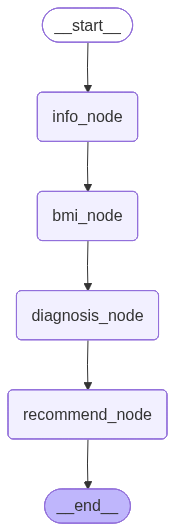

In [7]:
# 7: Visualize Graph
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
#8:Example

result = graph.invoke({
    "weight": 80,
    "height": 1.7
})

print(result)

{'name': 'John', 'weight': 80, 'height': 1.7, 'bmi': 27.68166089965398, 'diagnosis': 'Overweight', 'recommendation': 'Exercise and diet control'}
